# 重み以外のパラメータ可視化ノート
このノートブックは、weight 以外のパラメータを可視化・量子化を行う。
ヒストグラムとヒートマップで分布を確認し、必要に応じて量子化後の見え方も比較する。

## 読み方
1. まずチェックポイントの構造を確認
2. 次に weight / sensory weight の分布を見る
3. さらに weight 以外のパラメータを個別に確認
4. 最後に分布復元と量子化の補助関数を使う

In [12]:
# --- 修正版: JSON(config) と PyTorch(checkpoint) を分けて読む ---
import os
import json
import torch

#path = "/work/robomimic/bc_trained_models/lift/ncp-pure-best/ph/unit64/seed1/config.json"
# 例: 重みを見たいならこちらに差し替え
path = "/work/robomimic/bc_trained_models/lift/ncp-post/model_epoch_50_low_dim_v15_success_0.62.pth"

def dump_dict(d, prefix=""):
    if isinstance(d, dict):
        for k, v in d.items():
            name = f"{prefix}{k}"
            if isinstance(v, dict):
                print(f"{name}/")
                dump_dict(v, prefix=name + ".")
            elif torch.is_tensor(v):
                print(f"{name:60s} | shape={tuple(v.shape)} | dtype={v.dtype}")
            else:
                print(f"{name:60s} | type={type(v)}")
    else:
        # dict以外が来たときの保険
        print(f"{prefix.rstrip('.')}: {type(d)}")

ext = os.path.splitext(path)[1].lower()

if ext == ".json":
    with open(path) as f:
        cfg = json.load(f)
    dump_dict(cfg)
else:
    ckpt = torch.load(path, map_location="cpu")
    state = ckpt["state_dict"] if isinstance(ckpt, dict) and "state_dict" in ckpt else ckpt
    dump_dict(state["model"] if isinstance(state, dict) and "model" in state else state)

nets/
nets.policy.core.rnn_cell.gleak                              | shape=(64,) | dtype=torch.float32
nets.policy.core.rnn_cell.vleak                              | shape=(64,) | dtype=torch.float32
nets.policy.core.rnn_cell.cm                                 | shape=(64,) | dtype=torch.float32
nets.policy.core.rnn_cell.sigma                              | shape=(64,) | dtype=torch.float32
nets.policy.core.rnn_cell.mu                                 | shape=(64,) | dtype=torch.float32
nets.policy.core.rnn_cell.w                                  | shape=(64, 64) | dtype=torch.float32
nets.policy.core.rnn_cell.erev                               | shape=(64, 64) | dtype=torch.float32
nets.policy.core.rnn_cell.sensory_w                          | shape=(19, 64) | dtype=torch.float32
nets.policy.core.rnn_cell.sensory_erev                       | shape=(19, 64) | dtype=torch.float32
nets.policy.core.rnn_cell.sparsity_mask                      | shape=(64, 64) | dtype=torch.float32
nets.poli

## セクション1: チェックポイントの構造確認
JSON 設定と PyTorch checkpoint のどちらでも、中身の階層とテンソル形状を一覧表示する。

Loading checkpoint: /work/robomimic/bc_trained_models/lift/ncp-pure-best/ph/unit128/seed1/models/model_epoch_100_low_dim_v15_success_1.0.pth


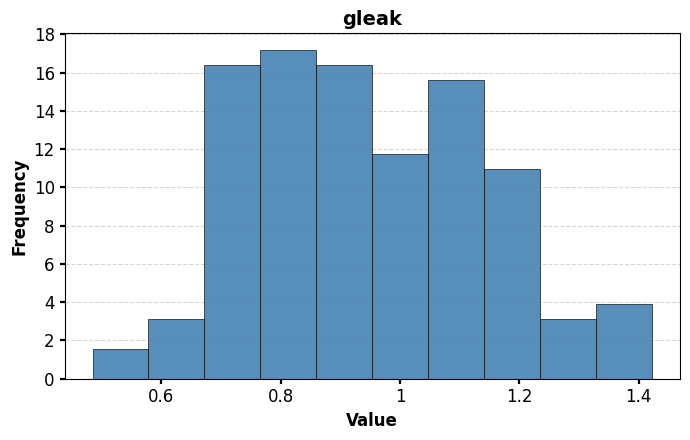

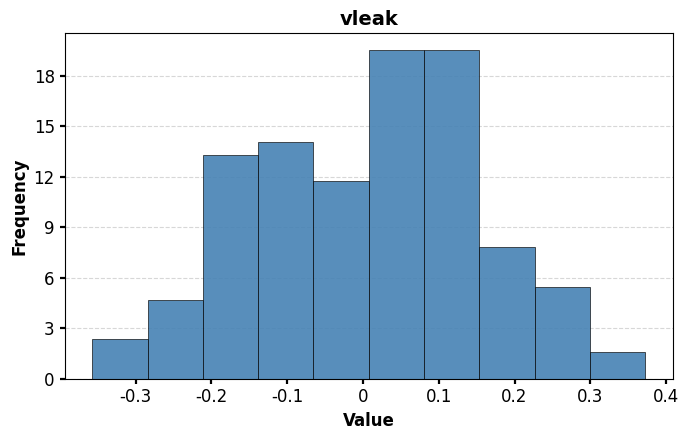

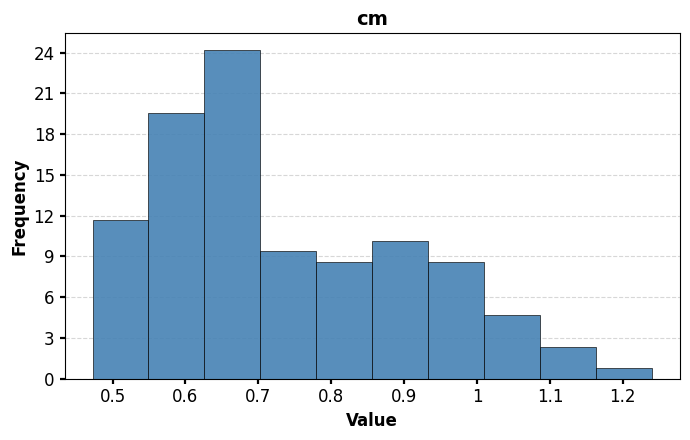

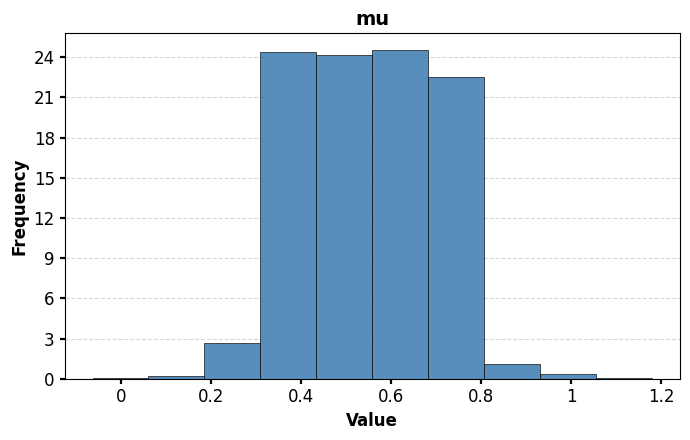

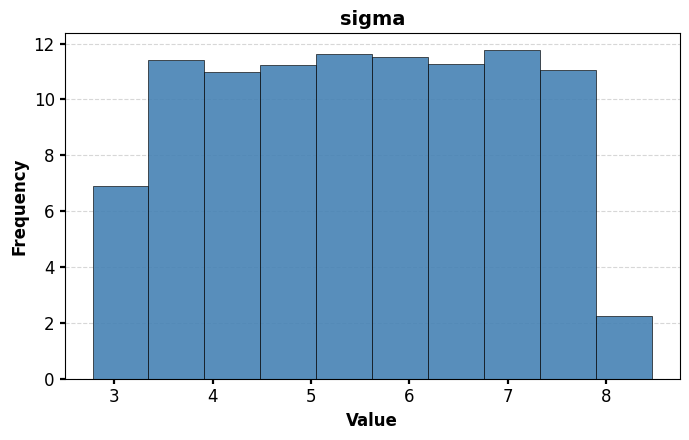

In [9]:
import torch
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
import torch.nn.functional as F
from matplotlib.colors import TwoSlopeNorm
from matplotlib.ticker import FuncFormatter

def flatten(d, prefix=""):
    out = {}
    for k, v in d.items():
        k = str(k)
        if isinstance(v, dict):
            out.update(flatten(v, prefix + k + "."))
        else:
            out[prefix + k] = v
    return out

def plot_separated_stages(checkpoint_path: str):
    print(f"Loading checkpoint: {checkpoint_path}")
    try:
        state = torch.load(checkpoint_path, map_location="cpu")
    except FileNotFoundError:
        print("Error: Checkpoint file not found.")
        return

    if "state_dict" in state:
        state = state["state_dict"]

    flat = flatten(state)
    
    # 必要なキーを検索（部分一致）
    try:
        gleak = [k for k in flat if k.endswith("rnn_cell.gleak")][0]
        vleak = [k for k in flat if k.endswith("rnn_cell.vleak")][0]
        cm = [k for k in flat if k.endswith("rnn_cell.cm")][0]
        mu = [k for k in flat if k.endswith("rnn_cell.mu")][0]
        sigma = [k for k in flat if k.endswith("rnn_cell.sigma")][0]    
    except IndexError:
        print("Error: Could not find required keys (rnn_cell.w/mask/erev) in checkpoint.")
        return

    gleak = flat[gleak]
    vleak = flat[vleak]
    cm = flat[cm]
    mu = flat[mu]
    sigma = flat[sigma]

    # ---------------- 前処理 ----------------
    gleak = F.softplus(gleak) 
    cm = F.softplus(cm)
    stages = [
        ("gleak", gleak, "continuous"),
        ("vleak", vleak, "continuous"),
        ("cm", cm, "continuous"),
        ("mu", mu, "continuous"),
        ("sigma", sigma, "continuous"),
    ]

    for name, data, mode in stages:
        arr = data.detach().cpu().numpy().flatten()
        
        # --- スパース性の計算 ---
        total_count = len(arr)
        nz = arr

        # ---------------- ヒストグラム ----------------
        plt.figure(figsize=(7, 4.5)) # 少し横長に

        if len(nz) == 0:
            plt.text(0.5, 0.5, "All values are Zero", ha='center', va='center', fontsize=14)
        else:
            if mode == "continuous":
                weights = np.ones_like(nz) / len(nz) * 100
                plt.hist(
                    nz,
                    bins=10,
                    weights=weights,
                    color="steelblue",
                    edgecolor="black",
                    linewidth=0.5,
                    zorder=2,
                    alpha=0.9
                )
            else:
                vals, counts = np.unique(nz, return_counts=True)
                weights = counts / counts.sum() * 100
                step = np.min(np.diff(vals)) if len(vals) > 1 else 0.2
                plt.bar(
                    vals,
                    weights,
                    width=step * 0.6,
                    color="steelblue",
                    edgecolor="black",
                    zorder=2,
                    alpha=0.9
                )

        ax = plt.gca()
        
        ax.set_title(f"{name}", fontsize=14, fontweight='bold')
        ax.set_ylabel("Frequency", fontsize=12, fontweight='bold')
        ax.set_xlabel("Value", fontsize=12, fontweight='bold')

        ax.tick_params(axis="both", labelsize=12, width=1.6)
        
        # Y軸を整数目盛りにする（見やすさのため）
        ax.yaxis.set_major_locator(ticker.MaxNLocator(integer=True))
        
        # X軸フォーマット
        ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{x:.2g}")) # 指数表記回避

        # グリッド
        plt.grid(axis="y", linestyle="--", alpha=0.5)
        plt.tight_layout()
        plt.show()

path = "/work/robomimic/bc_trained_models/lift/ncp-pure-best/ph/unit128/seed1/models/model_epoch_100_low_dim_v15_success_1.0.pth"
plot_separated_stages(path)

## セクション2: weight / sensory weight の分布可視化
`w` と `sensory_w` を取り出し、マスク適用後の分布をヒストグラムで確認する。
`erev` を掛けた後の分布も並べて、符号や広がりの変化を比較した。

In [5]:
import torch

def ptq_weight_nonzero(
    params: torch.Tensor, 
    n_bits: int = 4, 
    percentile: float = 0.999, 
    gaussian: float = None, 
    symmetric: bool = True
):
    """
    ReRAM CiM向け: スパース性を維持しつつ、書き込み目標値の量子化と読み出しノイズを印加する関数
    
    Args:
        params: 重みテンソル (Float)
        n_bits: ビット数 (例: 4bitなら16レベル)
        percentile: 外れ値除去のためのクリッピング率 (0.999推奨)
        gaussian: 正規化されたノイズ標準偏差 (例: 0.3 = 1LSBの30%のノイズ)
        symmetric: True推奨 (2T2R差動ペア構成を想定)
    """
    assert n_bits >= 2
    if percentile > 1.0:
        percentile /= 100.0

    with torch.no_grad():
        # 元の重みをコピー (0の部分はここでコピーされたまま、最後までいじらない = 完全な0/OFF)
        x = params.to(torch.float32)
        out = x.clone()

        # ---------------------------------------------------
        # 1. Zero-Gating (物理的なスイッチOFF)
        # ---------------------------------------------------
        # 0以外の要素(Non-zero)だけを取り出す
        nz_mask = x != 0
        nz = x[nz_mask]

        if nz.numel() == 0:
            return out # 全て0ならそのまま返す

        # ---------------------------------------------------
        # 2. Clipping (書き込み目標範囲の決定)
        # ---------------------------------------------------
        # 外れ値があると1LSBの幅(scale)が歪むため、percentileでクリッピングする
        if symmetric:
            abs_nz = nz.abs()
            max_val = torch.quantile(abs_nz, percentile)
            # ReRAMは正負対称のダイナミックレンジを持つと仮定
            nz = torch.clamp(nz, min=-max_val, max=max_val)
        else:
            # 非対称の場合はmin/maxを使う
            lower = torch.quantile(nz, 1 - percentile)
            upper = torch.quantile(nz, percentile)
            nz = torch.clamp(nz, min=lower, max=upper)

        # ---------------------------------------------------
        # 3. Quantization (書き込み: Target Conductanceの決定)
        # ---------------------------------------------------
        if symmetric:
            # [重要] 0をレベルとして確保するため、最大レベルを (2^(N-1) - 1) にする
            # 例 4bit: 符号1bit + データ3bit => 最大値7 (-7 ~ +7, 0含む15レベル)
            qmax = 2 ** (n_bits - 1) - 1
            
            # 最大値をqmaxにマッピングするためのスケール(1LSBの幅)を計算
            abs_max_clipped = nz.abs().max()
            if abs_max_clipped < 1e-12: return out
            
            scale = abs_max_clipped / qmax
            
            # ここで「書き込み目標値」が決まる (整数レベルに丸めて、スケール倍する)
            # これが "Ideal Written Weight"
            nz_target = torch.round(nz / scale).clamp(-qmax, qmax) * scale

        else:
            # Asymmetric (Unsigned想定だが、重みは通常SignedなのでReRAMではあまり使わない)
            qmax = 2 ** n_bits - 2
            min_val = nz.min()
            max_val = nz.max()
            if max_val - min_val < 1e-12: return out
            
            scale = (max_val - min_val) / qmax
            nz_target = torch.round((nz - min_val) / scale).clamp(0, qmax) * scale + min_val

        # ---------------------------------------------------
        # 4. Noise Injection (読み出し: Analog Readout Noise)
        # ---------------------------------------------------
        # ADCを通す前の「アナログ電流値」をシミュレートする。
        # したがって、ノイズ加算後は round(丸め) してはいけない。
        
        if gaussian is not None and gaussian > 0.0:
            # ノイズの定義: 1LSB (scale) に対する割合
            # normalized_sigma = gaussian * scale
            noise = torch.randn_like(nz_target) * gaussian * scale
            
            # [物理現象] ターゲット値 + ノイズ
            # これが実際にMVM演算に使われるコンダクタンス
            nz_noisy = nz_target + noise
            
            # [物理制約] デバイスのダイナミックレンジ(飽和)
            # ノイズが乗っても、物理的な最大コンダクタンス以上は流れない
            if symmetric:
                # abs_max_clipped はその層の最大コンダクタンス相当
                nz_final = nz_noisy.clamp(-abs_max_clipped, abs_max_clipped)
            else:
                nz_final = nz_noisy.clamp(min_val, max_val)
        else:
            nz_final = nz_target

        # ---------------------------------------------------
        # 5. Write Back
        # ---------------------------------------------------
        # 計算した非ゼロ部分だけを元のテンソルに戻す
        # (nz_mask以外、つまり0の部分は触っていないので 0.0 のまま = ノイズレス)
        out[nz_mask] = nz_final

        return out.to(params.dtype)

## セクション3: ReRAM 向け量子化関数
スパース性を保ちながら、非ゼロ要素だけを量子化し、必要なら読み出しノイズも加える。

Loading checkpoint: /work/robomimic/bc_trained_models/lift/ncp-pure-best/ph/unit128/seed1/models/model_epoch_100_low_dim_v15_success_1.0.pth
Combined shape (with zeros): (18816,)
Combined shape (nonzero only): (2654,)
Combined (erev) shape (with zeros): (18816,)
Combined (erev) shape (nonzero only): (2654,)


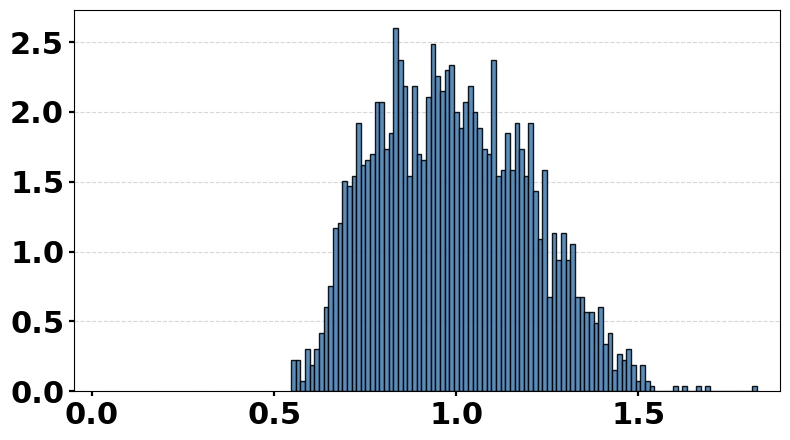

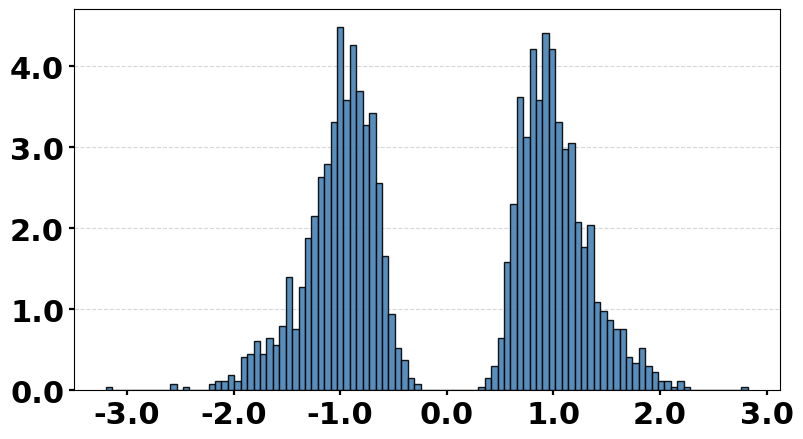

In [6]:
import torch
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
import torch.nn.functional as F
from matplotlib.colors import TwoSlopeNorm
from matplotlib.ticker import FuncFormatter

def flatten(d, prefix=""):
    out = {}
    for k, v in d.items():
        k = str(k)
        if isinstance(v, dict):
            out.update(flatten(v, prefix + k + "."))
        else:
            out[prefix + k] = v
    return out

def plot_combined_w_and_sensory_w(checkpoint_path: str):
    print(f"Loading checkpoint: {checkpoint_path}")
    try:
        state = torch.load(checkpoint_path, map_location="cpu")
    except FileNotFoundError:
        print("Error: Checkpoint file not found.")
        return

    if "state_dict" in state:
        state = state["state_dict"]

    def flatten(d, prefix=""):
        out = {}
        for k, v in d.items():
            k = str(k)
            if isinstance(v, dict):
                out.update(flatten(v, prefix + k + "."))
            else:
                out[prefix + k] = v
        return out

    flat = flatten(state)

    try:
        w_key = [k for k in flat if k.endswith("rnn_cell.w")][0]
        mask_key = [k for k in flat if k.endswith("rnn_cell.sparsity_mask")][0]
        sensory_w_key = [k for k in flat if k.endswith("rnn_cell.sensory_w")][0]
        sensory_mask_key = [k for k in flat if k.endswith("rnn_cell.sensory_sparsity_mask")][0]
        erev_key = [k for k in flat if k.endswith("rnn_cell.erev")][0]
        sensory_erev_key = [k for k in flat if k.endswith("rnn_cell.sensory_erev")][0]
    except IndexError:
        print("Error: Could not find required keys (rnn_cell.w/sensory_w/mask/erev) in checkpoint.")
        return

    w = flat[w_key]
    mask = flat[mask_key]
    sensory_w = flat[sensory_w_key]
    sensory_mask = flat[sensory_mask_key]
    erev = flat[erev_key]
    sensory_erev = flat[sensory_erev_key]

    # softplus & mask
    w_masked = F.softplus(w) * mask
    sensory_w_masked = F.softplus(sensory_w) * sensory_mask

    # erevをかける
    w_masked_erev = w_masked * erev
    sensory_w_masked_erev = sensory_w_masked * sensory_erev

    # 結合: 行列を1次元にflattenして連結
    combined = torch.cat([w_masked.flatten(), sensory_w_masked.flatten()], dim=0)
    combined_erev = torch.cat([w_masked_erev.flatten(), sensory_w_masked_erev.flatten()], dim=0)

    arr = combined.detach().cpu().numpy()
    arr_nz = arr[arr != 0]
    arr_erev = combined_erev.detach().cpu().numpy()
    arr_erev_nz = arr_erev[arr_erev != 0]

    print(f"Combined shape (with zeros): {arr.shape}")
    print(f"Combined shape (nonzero only): {arr_nz.shape}")
    print(f"Combined (erev) shape (with zeros): {arr_erev.shape}")
    print(f"Combined (erev) shape (nonzero only): {arr_erev_nz.shape}")

    # --- softplus&mask のヒストグラム ---
    if len(arr_nz) > 0:
        plt.figure(figsize=(8, 4.5))
        weights = np.ones_like(arr_nz) / len(arr_nz) * 100
        bins = 200 if np.any(arr_nz < 0) else 100
        plt.hist(arr_nz, bins=bins, weights=weights, color="steelblue", edgecolor="black", alpha=0.9, zorder=2)
        ax = plt.gca()
        ax.xaxis.set_major_formatter(ticker.FormatStrFormatter('%.1f'))
        ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.1f'))
        ax.tick_params(axis="both", labelsize=22, width=1.6)
        for lbl in ax.get_xticklabels() + ax.get_yticklabels():
            lbl.set_fontweight("bold")
        plt.grid(axis="y", linestyle="--", alpha=0.5)
        plt.xlim(-0.05, None)
        plt.tight_layout()
        plt.show()

    # --- erevをかけた後のヒストグラム ---
    if len(arr_erev_nz) > 0:
        plt.figure(figsize=(8, 4.5))
        weights = np.ones_like(arr_erev_nz) / len(arr_erev_nz) * 100
        bins = 100 if np.any(arr_erev_nz < 0) else 100
        plt.hist(arr_erev_nz, bins=bins, weights=weights, color="steelblue", edgecolor="black", alpha=0.9, zorder=2)
        ax = plt.gca()
        ax.xaxis.set_major_formatter(ticker.FormatStrFormatter('%.1f'))
        ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.1f'))
        ax.tick_params(axis="both", labelsize=22, width=1.6)
        for lbl in ax.get_xticklabels() + ax.get_yticklabels():
            lbl.set_fontweight("bold")
        plt.grid(axis="y", linestyle="--", alpha=0.5)
        plt.tight_layout()
        plt.show()

# 使い方例
path = "/work/robomimic/bc_trained_models/lift/ncp-pure-best/ph/unit128/seed1/models/model_epoch_100_low_dim_v15_success_1.0.pth"

plot_combined_w_and_sensory_w(path)

## セクション4: weight と sensory weight の比較
通常の重みと感覚入力側の重みをまとめて可視化し、スケールや符号の違いを見る。

Loading checkpoint: /work/robomimic/bc_trained_models/lift/ncp-pure-best/ph/unit128/seed1/models/model_epoch_100_low_dim_v15_success_1.0.pth


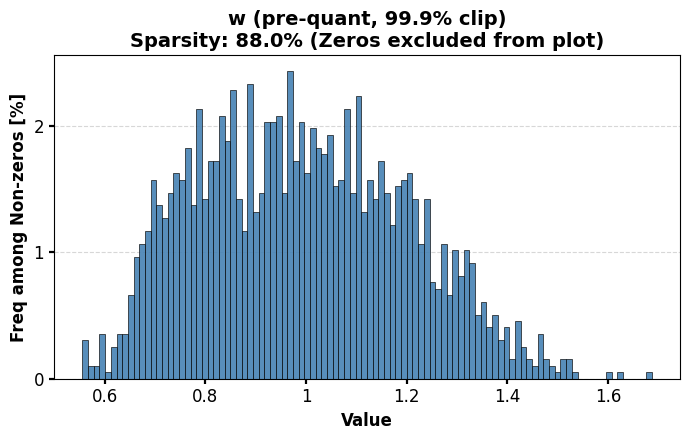

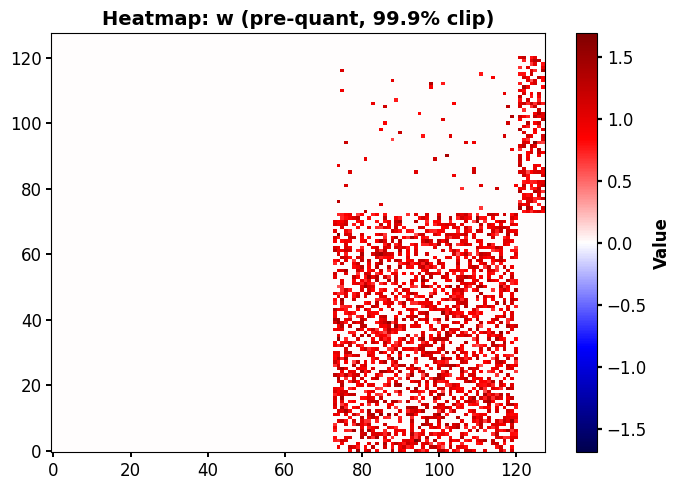

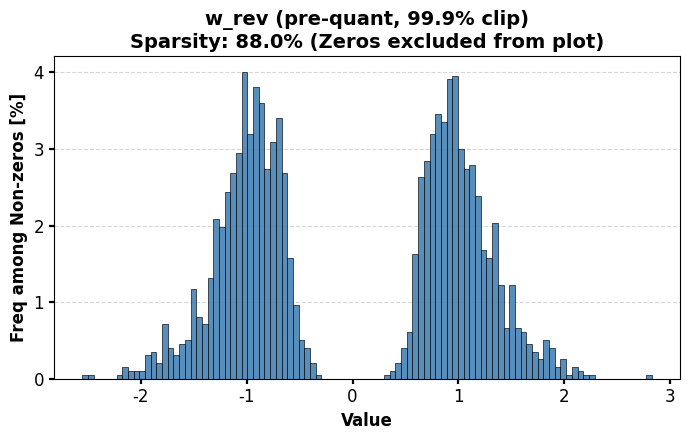

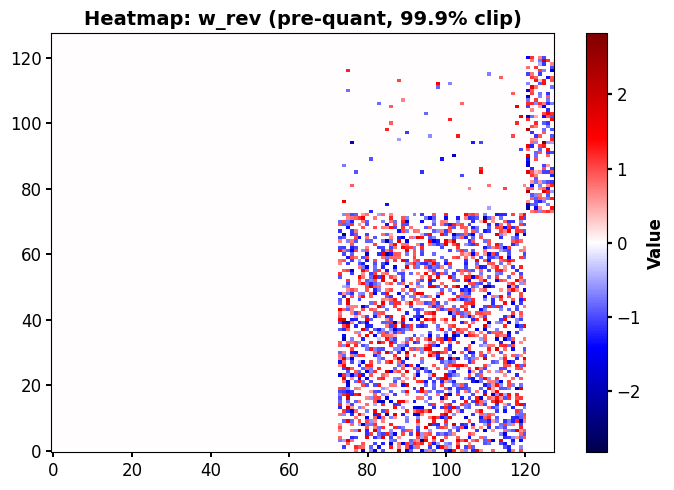

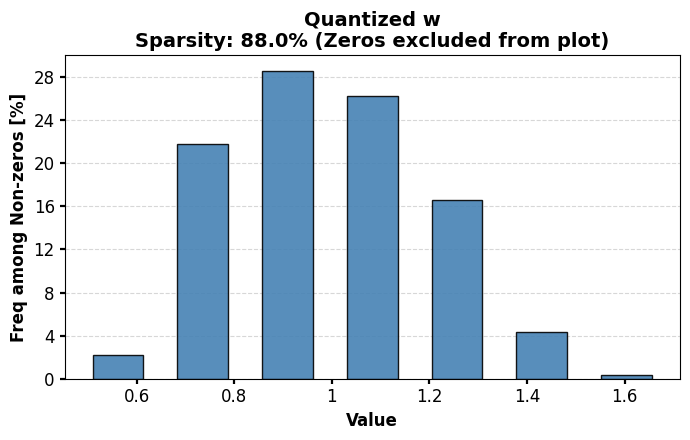

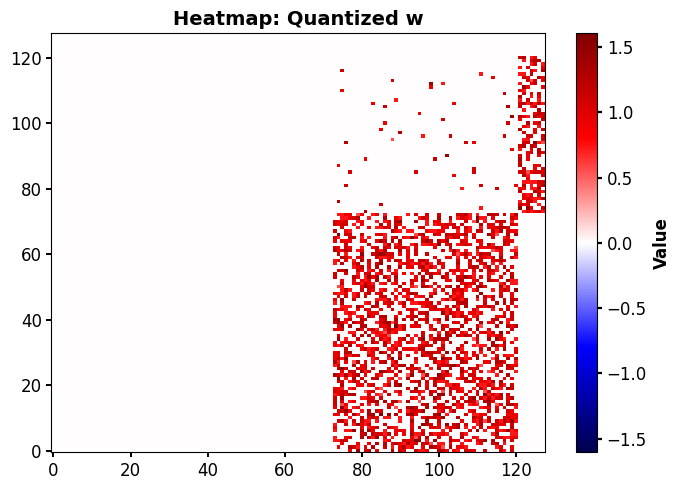

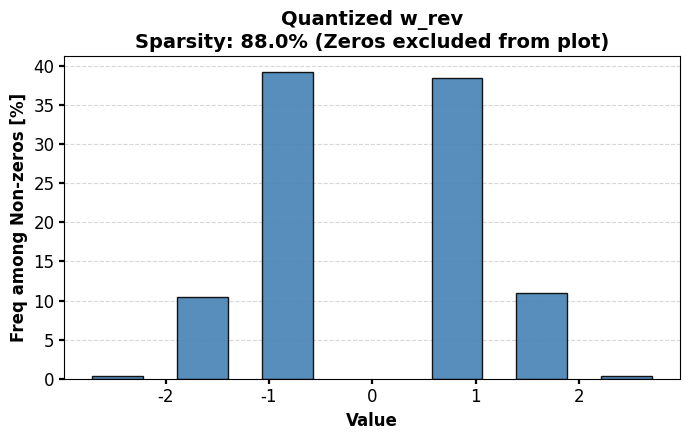

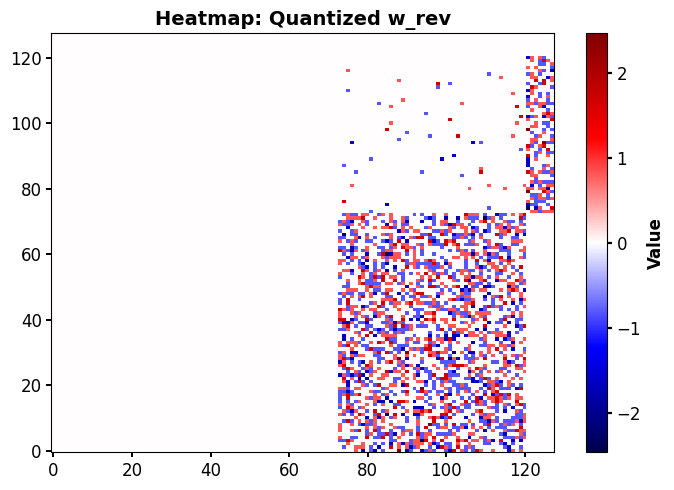

In [7]:
import torch
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
import torch.nn.functional as F
from matplotlib.colors import TwoSlopeNorm
from matplotlib.ticker import FuncFormatter

# 出力省略の解除
np.set_printoptions(threshold=np.inf)

# ------------------------------------------------------------------
# state_dict flatten（int key 対応）
# ------------------------------------------------------------------
def flatten(d, prefix=""):
    out = {}
    for k, v in d.items():
        k = str(k)
        if isinstance(v, dict):
            out.update(flatten(v, prefix + k + "."))
        else:
            out[prefix + k] = v
    return out

def reorder_neurons(mat, order=None):
    """
    ニューロンの順番を「浅い層ほど番号が若い（左上）」になるように並べ替える。
    order: 並べ替えたいインデックスのリスト（例: [63,62,...,0] なら上下左右反転）
    """
    if order is None:
        # デフォルト: 上下左右反転（例: 64ユニットなら [63,62,...,0]）
        order = list(reversed(range(mat.shape[0])))
    mat_reordered = mat[np.ix_(order, order)]
    return mat_reordered

# ------------------------------------------------------------------
# プロット関数（修正版）
# ------------------------------------------------------------------
def plot_separated_stages(checkpoint_path: str):
    print(f"Loading checkpoint: {checkpoint_path}")
    try:
        state = torch.load(checkpoint_path, map_location="cpu")
    except FileNotFoundError:
        print("Error: Checkpoint file not found.")
        return

    if "state_dict" in state:
        state = state["state_dict"]

    flat = flatten(state)
    
    # 必要なキーを検索（部分一致）
    try:
        w_key = [k for k in flat if k.endswith("rnn_cell.w")][0]
        mask_key = [k for k in flat if k.endswith("rnn_cell.sparsity_mask")][0]
        erev_key = [k for k in flat if k.endswith("rnn_cell.erev")][0]
    except IndexError:
        print("Error: Could not find required keys (rnn_cell.w/mask/erev) in checkpoint.")
        return

    w = flat[w_key]
    mask = flat[mask_key]
    erev = flat[erev_key]

    # ---------------- 前処理 ----------------
    w_masked = F.softplus(w) * mask
    w_rev = w_masked * erev
    stages = [
        ("w (pre-quant, 99.9% clip)", w_masked, "continuous"),
        ("w_rev (pre-quant, 99.9% clip)", w_rev, "continuous"),
        ("Quantized w", ptq_weight_nonzero(w_masked.clone(), n_bits=3, percentile=99.9, symmetric=False), "discrete"),
        ("Quantized w_rev", ptq_weight_nonzero(w_rev.clone(), n_bits=3, percentile=99.9, symmetric=True), "discrete"),
    ]

    for name, data, mode in stages:
        arr = data.detach().cpu().numpy().flatten()
        
        # --- スパース性の計算 ---
        total_count = len(arr)
        zero_count = np.sum(arr == 0)
        sparsity = zero_count / total_count
        nz = arr[arr != 0]

        # ---------------- ヒストグラム ----------------
        plt.figure(figsize=(7, 4.5)) # 少し横長に

        if len(nz) == 0:
            plt.text(0.5, 0.5, "All values are Zero", ha='center', va='center', fontsize=14)
        else:
            if mode == "continuous":
                # 重みを「非ゼロ要素数」に対する割合にする
                weights = np.ones_like(nz) / len(nz) * 100
                plt.hist(
                    nz,
                    bins=100,
                    weights=weights,
                    color="steelblue",
                    edgecolor="black",
                    linewidth=0.5,
                    zorder=2,
                    alpha=0.9
                )
            else:
                # 離散値のプロット
                vals, counts = np.unique(nz, return_counts=True)
                weights = counts / counts.sum() * 100
                # 棒の幅を自動調整
                step = np.min(np.diff(vals)) if len(vals) > 1 else 0.2
                plt.bar(
                    vals,
                    weights,
                    width=step * 0.6,
                    color="steelblue",
                    edgecolor="black",
                    zorder=2,
                    alpha=0.9
                )

        ax = plt.gca()
        
        # タイトルにスパース率を表示（これが重要！）
        ax.set_title(f"{name}\nSparsity: {sparsity:.1%} (Zeros excluded from plot)", fontsize=14, fontweight='bold')
        ax.set_ylabel("Freq among Non-zeros [%]", fontsize=12, fontweight='bold')
        ax.set_xlabel("Value", fontsize=12, fontweight='bold')

        ax.tick_params(axis="both", labelsize=12, width=1.6)
        
        # Y軸を整数目盛りにする（見やすさのため）
        ax.yaxis.set_major_locator(ticker.MaxNLocator(integer=True))
        
        # X軸フォーマット
        ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{x:.2g}")) # 指数表記回避

        # グリッド
        plt.grid(axis="y", linestyle="--", alpha=0.5)
        plt.tight_layout()
        plt.show()

        # ---------------- ヒートマップ ----------------
        # 0とそれ以外を視覚的に区別しやすいようにプロット
        mat = data.detach().cpu().numpy()
        mat = reorder_neurons(mat)
        
        # 最大値で正規化範囲を決定
        vmax = np.max(np.abs(mat))
        if vmax == 0: vmax = 1.0
        norm = TwoSlopeNorm(vmin=-vmax, vcenter=0.0, vmax=vmax)

        plt.figure(figsize=(7, 5))
        plt.imshow(
            mat,
            cmap="seismic",
            norm=norm,
            aspect="auto",
            interpolation="nearest",
            origin="lower" # 行列の上下を合わせる
        )
        cbar = plt.colorbar()
        cbar.ax.tick_params(labelsize=12, width=1.6)
        cbar.set_label("Value", fontweight='bold', fontsize=12)
        
        ax = plt.gca()
        ax.set_title(f"Heatmap: {name}", fontsize=14, fontweight='bold')
        ax.tick_params(axis="both", labelsize=12, width=1.4)

        plt.tight_layout()
        plt.show()

# ------------------------------------------------------------------
# 実行パスの設定
# ------------------------------------------------------------------
# パスは環境に合わせて変更してください
path = "/work/robomimic/bc_trained_models/lift/ncp-pure-best/ph/unit128/seed1/models/model_epoch_100_low_dim_v15_success_1.0.pth"
plot_separated_stages(path)

## セクション5: LUTに保存する値の量子化範囲の決定
キャリブレーションによる最大と最小からクリッピングの範囲を決定する（99.9%パーセンタイル法）

CDF 0.05–99.95%
[-1.555, 1.313]


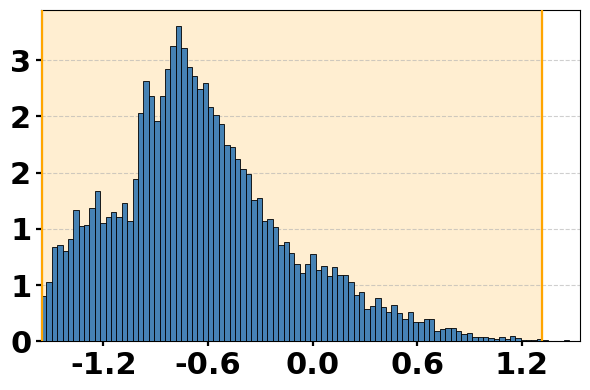

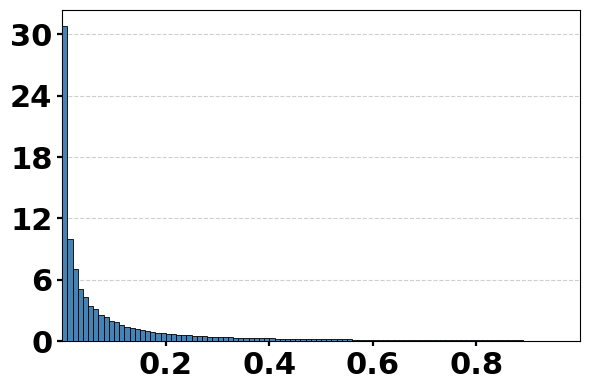

In [8]:
# ...existing code...
import numpy as np
import json, numpy as np, matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# =========================
# load
# =========================
with open("/work/robomimic/logs/quantize/all/calibration/u256/Seed1.json") as f:
    data = json.load(f)

if not data:
    raise ValueError("data is empty")

def plot_hist_resampled(
    data,
    key="states",
    n_bins=100,
    as_percent=False,
    title=None,
    percent_band=None,   # 追加: ここで「何%〜何%」を指定
    band_color="orange",
):
    mins, maxs = [], []
    for d in data:
        if key in d:
            mins.append(d[key]["min"])
            maxs.append(d[key]["max"])
    if not mins:
        raise ValueError(f"{key} not found")

    vmin, vmax = min(mins), max(maxs)
    edges_common = np.linspace(vmin, vmax, n_bins + 1)
    widths = np.diff(edges_common)
    centers = 0.5 * (edges_common[:-1] + edges_common[1:])

    # hist_sum は「density相当」を足し上げている（cnt / bin_width）
    hist_sum = np.zeros(n_bins, dtype=float)

    for d in data:
        if key not in d:
            continue
        h = np.asarray(d[key]["hist"], dtype=float)
        step_min = d[key]["min"]
        step_max = d[key]["max"]

        edges_step = np.linspace(step_min, step_max, len(h) + 1)
        centers_step = 0.5 * (edges_step[:-1] + edges_step[1:])
        widths_step = np.diff(edges_step)

        for c, cnt, w in zip(centers_step, h, widths_step):
            idx = np.searchsorted(edges_common, c, side="right") - 1
            if 0 <= idx < n_bins:
                hist_sum[idx] += (cnt / w) if (w > 0) else cnt

    # ---- 何%の範囲(=CDF)を可視化するために「確率質量」を作る ----
    # density * dx -> mass（各ビンが全体の何%を占めるか）
    mass = hist_sum * widths
    mass_total = mass.sum()

    # percent_band から x 座標を求める（累積分布を edges 上で補間）
    x_lo = x_hi = None
    if percent_band is not None and mass_total > 0:
        lo, hi = percent_band
        lo = float(lo); hi = float(hi)
        if not (0.0 <= lo <= 100.0 and 0.0 <= hi <= 100.0 and lo < hi):
            raise ValueError("percent_band must satisfy 0<=lo<hi<=100")

        cdf_edges = np.concatenate([[0.0], np.cumsum(mass)]) / mass_total * 100.0  # len = n_bins+1
        x_lo = float(np.interp(lo, cdf_edges, edges_common))
        x_hi = float(np.interp(hi, cdf_edges, edges_common))

    # ---- 表示用に % 正規化（y 軸表示） ----
    y = hist_sum.copy()
    if as_percent:
        if y.sum() > 0:
            y = y / y.sum() * 100.0

    plt.figure(figsize=(6, 4))
    plt.bar(
        centers, y, width=widths, align="center",
        edgecolor="black", linewidth=0.6, color="steelblue", zorder=3
    )
    plt.xlim(vmin, vmax)


    # ---- 「何%の範囲はここ」を重ねて表示 ----
    ax = plt.gca()
    ax.xaxis.set_major_formatter(ticker.FormatStrFormatter('%.1f'))
    ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.0f'))
    if x_lo is not None and x_hi is not None:
        ax.axvspan(x_lo, x_hi, color=band_color, alpha=0.18, zorder=1, label=f"{percent_band[0]:g}–{percent_band[1]:g}%")
        ax.axvline(x_lo, color=band_color, linewidth=1.6, zorder=4)
        ax.axvline(x_hi, color=band_color, linewidth=1.6, zorder=4)
        print(f"CDF {percent_band[0]:g}–{percent_band[1]:g}%\n[{x_lo:.4g}, {x_hi:.4g}]")


    ax.yaxis.set_major_locator(ticker.MaxNLocator(6))
    ax.xaxis.set_major_locator(ticker.MaxNLocator(6))
    plt.tick_params(axis="both", labelsize=22, width=1.6)
    for lbl in ax.get_xticklabels() + ax.get_yticklabels():
        lbl.set_fontweight("bold")
    plt.grid(axis="y", linestyle="--", alpha=0.6)
    plt.tight_layout()
    plt.show()

# 例: 中央90% (= 5–95%) を表示
plot_hist_resampled(data, key="states", n_bins=100, as_percent=True, title="States histogram", percent_band=(0.05, 99.95))
plot_hist_resampled(data, key="activations", n_bins=100, as_percent=True, title="Activations histogram")
# ...existing code...

## セクション6: 分布からのクリップ範囲推定と量子化
ヒストグラムから CDF ベースで clip 範囲を推定し、その範囲で量子化する

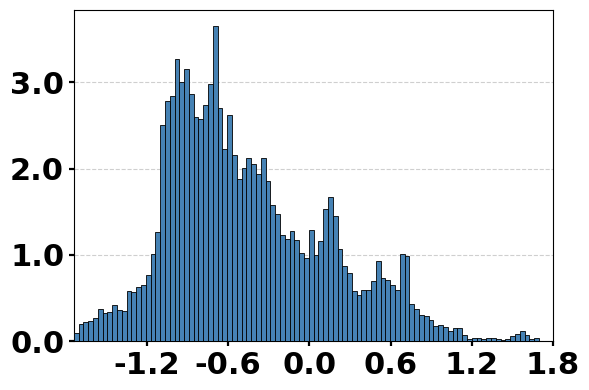

In [9]:
# ...existing code...
import numpy as np
import json, numpy as np, matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# =========================
# load
# =========================
with open("/work/robomimic/logs/quantize/all/calibration/u256/Seed4.json") as f:
    data = json.load(f)

if not data:
    raise ValueError("data is empty")

def plot_hist_resampled(
    data,
    key="states",
    n_bins=100,
    as_percent=False,
    title=None,
    percent_band=None,   
):
    mins, maxs = [], []
    for d in data:
        if key in d:
            mins.append(d[key]["min"])
            maxs.append(d[key]["max"])
    if not mins:
        raise ValueError(f"{key} not found")

    vmin, vmax = min(mins), max(maxs)
    edges_common = np.linspace(vmin, vmax, n_bins + 1)
    widths = np.diff(edges_common)
    centers = 0.5 * (edges_common[:-1] + edges_common[1:])

    # hist_sum は「density相当」を足し上げている（cnt / bin_width）
    hist_sum = np.zeros(n_bins, dtype=float)

    for d in data:
        if key not in d:
            continue
        h = np.asarray(d[key]["hist"], dtype=float)
        step_min = d[key]["min"]
        step_max = d[key]["max"]

        edges_step = np.linspace(step_min, step_max, len(h) + 1)
        centers_step = 0.5 * (edges_step[:-1] + edges_step[1:])
        widths_step = np.diff(edges_step)

        for c, cnt, w in zip(centers_step, h, widths_step):
            idx = np.searchsorted(edges_common, c, side="right") - 1
            if 0 <= idx < n_bins:
                hist_sum[idx] += (cnt / w) if (w > 0) else cnt

    # ---- 何%の範囲(=CDF)を可視化するために「確率質量」を作る ----
    # density * dx -> mass（各ビンが全体の何%を占めるか）
    mass = hist_sum * widths
    mass_total = mass.sum()

    # percent_band から x 座標を求める（累積分布を edges 上で補間）
    x_lo = x_hi = None
    if percent_band is not None and mass_total > 0:
        lo, hi = percent_band
        lo = float(lo); hi = float(hi)
        if not (0.0 <= lo <= 100.0 and 0.0 <= hi <= 100.0 and lo < hi):
            raise ValueError("percent_band must satisfy 0<=lo<hi<=100")

        cdf_edges = np.concatenate([[0.0], np.cumsum(mass)]) / mass_total * 100.0  # len = n_bins+1
        x_lo = float(np.interp(lo, cdf_edges, edges_common))
        x_hi = float(np.interp(hi, cdf_edges, edges_common))

    # ---- 表示用に % 正規化（y 軸表示） ----
    y = hist_sum.copy()
    if as_percent:
        if y.sum() > 0:
            y = y / y.sum() * 100.0

    plt.figure(figsize=(6, 4))
    plt.bar(
        centers, y, width=widths, align="center",
        edgecolor="black", linewidth=0.6, color="steelblue", zorder=3
    )
    plt.xlim(vmin, vmax)


    # ---- 「何%の範囲はここ」を重ねて表示 ----
    ax = plt.gca()
    ax.xaxis.set_major_formatter(ticker.FormatStrFormatter('%.1f'))
    ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.1f'))

    ax.yaxis.set_major_locator(ticker.MaxNLocator(4))
    ax.xaxis.set_major_locator(ticker.MaxNLocator(6))
    plt.tick_params(axis="both", labelsize=22, width=1.6)
    for lbl in ax.get_xticklabels() + ax.get_yticklabels():
        lbl.set_fontweight("bold")
    plt.grid(axis="y", linestyle="--", alpha=0.6)
    plt.tight_layout()
    plt.show()

# 例: 中央90% (= 5–95%) を表示
plot_hist_resampled(data, key="states", n_bins=100, as_percent=True, title="States histogram")

In [10]:
# =========================
# 分布から clip 範囲を計算
# =========================
def get_clip_range_from_hist(data, key="states", percent_band=(5, 95), n_bins=200):
    mins, maxs = [], []
    for d in data:
        if key in d:
            mins.append(d[key]["min"])
            maxs.append(d[key]["max"])
    if not mins:
        raise ValueError(f"{key} not found")

    vmin, vmax = min(mins), max(maxs)
    edges_common = np.linspace(vmin, vmax, n_bins + 1)
    widths = np.diff(edges_common)

    hist_sum = np.zeros(n_bins, dtype=float)

    for d in data:
        if key not in d:
            continue
        h = np.asarray(d[key]["hist"], dtype=float)
        step_min = d[key]["min"]
        step_max = d[key]["max"]

        edges_step = np.linspace(step_min, step_max, len(h) + 1)
        centers_step = 0.5 * (edges_step[:-1] + edges_step[1:])
        widths_step = np.diff(edges_step)

        for c, cnt, w in zip(centers_step, h, widths_step):
            idx = np.searchsorted(edges_common, c, side="right") - 1
            if 0 <= idx < n_bins:
                hist_sum[idx] += (cnt / w) if (w > 0) else cnt

    mass = hist_sum * widths
    mass_total = mass.sum()

    if mass_total == 0:
        raise ValueError("Histogram mass is zero")

    lo, hi = percent_band
    cdf_edges = np.concatenate([[0.0], np.cumsum(mass)]) / mass_total * 100.0

    x_lo = float(np.interp(lo, cdf_edges, edges_common))
    x_hi = float(np.interp(hi, cdf_edges, edges_common))

    return x_lo, x_hi


# =========================
# clip + quantize
# =========================
def clip_and_quantize_from_range(
    x,
    clip_min,
    clip_max,
    num_bits=8,
    symmetric=True
):
    x = np.asarray(x, dtype=np.float32)

    # Clip
    x_clip = np.clip(x, clip_min, clip_max)

    if symmetric:
        abs_max = max(abs(clip_min), abs(clip_max))
        qmax = (1 << (num_bits - 1)) - 1
        scale = abs_max / qmax
        qmin = -qmax
    else:
        qmin = 0
        qmax = (1 << num_bits) - 1
        scale = (clip_max - clip_min) / (qmax - qmin)

    # Quantize
    q = np.round(x_clip / scale)
    q = np.clip(q, qmin, qmax)

    # Dequantize
    x_quant = q * scale

    return x_quant, scale

def reconstruct_samples_from_hist(data, key="states"):
    samples = []

    for d in data:
        if key not in d:
            continue

        h = np.asarray(d[key]["hist"], dtype=int)
        vmin = d[key]["min"]
        vmax = d[key]["max"]

        edges = np.linspace(vmin, vmax, len(h) + 1)
        centers = 0.5 * (edges[:-1] + edges[1:])

        for c, cnt in zip(centers, h):
            samples.extend([c] * int(cnt))

    return np.array(samples, dtype=np.float32)


## セクション7: clip 範囲と量子化の補助関数
clip 範囲、量子化スケールを計算する

In [11]:
# 1️⃣ ヒストグラムからクリップ範囲取得
data = json.load(open("/work/robomimic/logs/quantize/all/calibration/u256/Seed1.json"))
clip_min, clip_max = get_clip_range_from_hist(
    data,
    key="states",
    percent_band=(0.05, 99.95),
)

print("Clip range:", clip_min, clip_max)

# 2️⃣ 実際の states データ（例）
states_array = reconstruct_samples_from_hist("/work/robomimic/logs/quantize/all/calibration/u256/Seed4.json")  # あなたの実データパス

# 3️⃣ 量子化
states_q, scale = clip_and_quantize_from_range(
    states_array,
    clip_min,
    clip_max,
    num_bits=4,
    symmetric=False
)

print("Quant scale:", scale)
print(states_q)

Clip range: -1.5506697872229194 1.299213007586062
Quant scale: 0.18999218632059875
[]


## セクション9: 量子化ヒストグラムの描画
量子化後のサンプル分布を % 表示のヒストグラムとして描画する　

ビン数や目盛りを調整して、離散化の見え方を確認しやすくしている

In [ ]:
def quantize_values(x, x_min=-1.550, scale=0.1899, qmin=0, qmax=15):
    q = np.round((x - x_min) / scale)
    q = np.clip(q, qmin, qmax)
    x_hat = q * scale + x_min
    return x_hat


def plot_quantized_hist_from_json(
    data,
    key="states",
    n_bins=40,
    title="Quantized histogram",
):
    # -------------------------
    # 1. ヒストグラムから疑似サンプル復元
    # -------------------------
    samples = []

    for d in data:
        if key not in d:
            continue

        h = np.asarray(d[key]["hist"], dtype=float)
        vmin = d[key]["min"]
        vmax = d[key]["max"]

        edges = np.linspace(vmin, vmax, len(h) + 1)
        centers = 0.5 * (edges[:-1] + edges[1:])

        for c, cnt in zip(centers, h):
            samples.extend([c] * int(cnt))

    samples = np.asarray(samples)
    if len(samples) == 0:
        raise ValueError("No samples reconstructed")

    # -------------------------
    # 2. 量子化
    # -------------------------
    q_samples = quantize_values(samples)

    # -------------------------
    # 3. proportion → % ヒストグラム
    # -------------------------
    weights = np.ones_like(q_samples) / len(q_samples) * 100.0  # ← % に変換

    plt.figure(figsize=(6, 4))
    plt.hist(
        q_samples,
        bins=n_bins,
        weights=weights,
        color="steelblue",
        edgecolor="black",
        linewidth=0.8,
        rwidth=1.50,
        zorder=3
    )

    ax = plt.gca()
    ax.set_ylim(0, 16)                         # ← 上限20%
    ax.set_yticks([0, 4, 8, 12, 16])       # ← 指定目盛り

    ax.xaxis.set_major_formatter(ticker.FormatStrFormatter('%.1f'))
    ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%d'))

    ax.yaxis.set_major_locator(ticker.FixedLocator([0, 4, 8, 12, 16]))
    ax.xaxis.set_major_locator(ticker.MaxNLocator(6))

    plt.tick_params(axis="both", labelsize=25, width=1.6)
    for lbl in ax.get_xticklabels() + ax.get_yticklabels():
        lbl.set_fontweight("bold")

    plt.grid(axis="y", linestyle="--", alpha=0.6, zorder=-3)
    plt.tight_layout()
    plt.show()


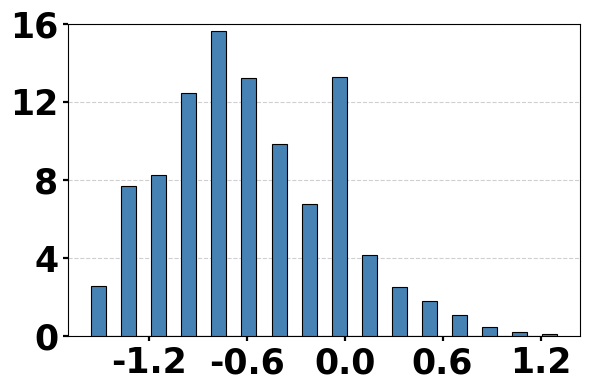

In [13]:
plot_quantized_hist_from_json(
    data,
    key="states",
    n_bins=31,
    title="States (4-bit Quantized)"
)


## セクション10: 量子化ヒストグラムの実行例
前のセルで定義した関数を使って、4bit 量子化の分布を実際に表示します。
このセルは確認用の実行入口です。